In [25]:
import json
import os
from os.path import join as ospj
import numpy as np
from src.utils.action_label_to_idx import action_label_to_idx
import clip
import torch

# Load the dataset

In [2]:
# #loads the BABEL data into a dictionary in the format {'train':{seq_id: sequence data}}
# data_folder = '../data/babel_v1.0_release'  
# l_babel_dense_files = ['train', 'val', 'test']
# l_babel_extra_files = ['extra_train', 'extra_val']

# babel = {}
# for file in l_babel_dense_files:
#     babel[file] = json.load(open(ospj(data_folder, file+'.json')))
    
# for file in l_babel_extra_files:
#     babel[file] = json.load(open(ospj(data_folder, file+'.json'))) 

## Create BABEL 120
### Restrict BABEL to 120 classes and make the seen and unseen dataset

In [3]:
# classes_120 = list(action_label_to_idx.keys())[:120]
# data = babel["train"]
# classes_seen = set(classes_120[:60])
# classes_unseen = set(classes_120[60:120])

# babel_seen = {
#     sid: seq for sid, seq in data.items()
#     if any(
#         (
#             isinstance(lab.get("act_cat"), str) and lab["act_cat"] in classes_seen
#         ) or (
#             isinstance(lab.get("act_cat"), list) and
#             any(cat in classes_seen for cat in lab["act_cat"])
#         )
#         for lab in seq.get("seq_ann", {}).get("labels", []) or []
#     ) 
# }

# babel_unseen = {
#     sid: seq for sid, seq in data.items()
#     if any(
#         (
#             isinstance(lab.get("act_cat"), str) and lab["act_cat"] in classes_unseen
#         ) or (
#             isinstance(lab.get("act_cat"), list) and
#             any(cat in classes_unseen for cat in lab["act_cat"])
#         )
#         for lab in seq.get("seq_ann", {}).get("labels", []) or []
#     )
# }
# print("len of the train data", len(list(babel["train"].keys())))
# print("len of the babel seen data", len(list(babel_seen.keys())))
# print("len of the babel unseen data", len(list(babel_unseen.keys())))

## Preprocess the data
### Downsample and cut window size

In [4]:
# # downsamples the motion to 30 fps and 60 windows
# def downsample_and_window(babel_split, data_root, target_fps=30, T=60, src_fps=120):
#     step = src_fps // target_fps  
#     windowed_clips = {}

#     for sid, seq in babel_split.items():
#         feat_path = seq.get("feat_p", "")
#         # if not feat_path.startswith("ACCAD/"):  
#         #     continue
#         print("inside")
#         npz_path = os.path.join(data_root, seq["feat_p"])
#         if not os.path.exists(npz_path):
#             continue

#         data = np.load(npz_path)
#         poses = data["poses"]  

#         # downsample to 30 Hz
#         poses_ds = poses[::step]

#         # make 60-frame windows (≈ 2 s each)
#         num_frames = poses_ds.shape[0]
#         clips = []
#         for start in range(0, num_frames - T + 1, T):
#             clip = poses_ds[start:start + T]
#             clips.append(clip)

#         if clips: 
#             windowed_clips[sid] = np.stack(clips)

#     return windowed_clips

In [5]:
# data_root = "data/babel_v1.0_release"  # adjust if needed

# babel_seen_clips = downsample_and_window(babel_seen, data_root)
# babel_unseen_clips = downsample_and_window(babel_unseen, data_root)

## Get text embeddings

In [26]:
# for 60 classes 
# make prompts into sentences and encodes it into text embeddings
classes_60 = list(action_label_to_idx.keys())[:60]
prompts = [f"a person performing {name}" for name in classes_60]

os.environ["CLIP_CACHE_DIR"] = "D:/clip_cache"

device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model, preprocess = clip.load("ViT-B/32", device=device, download_root=os.environ["CLIP_CACHE_DIR"])

with torch.no_grad():
    # convert text to tokens that CLIP can read
    tokens = clip.tokenize(prompts).to(device)

    #encode the text
    text_embeddings = clip_model.encode_text(tokens)

    # normalize to unit length (critical for cosine similarity)
    text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

In [27]:
torch.save(text_embeddings, '../data/text_embeddings_BABEL60_train_only.pt')

In [ ]:
# for 120 classes
# make prompts into sentences and encodes it into text embeddings
classes_120 = list(action_label_to_idx.keys())[:120]
prompts = [f"a person performing {name}" for name in classes_120]

os.environ["CLIP_CACHE_DIR"] = "D:/clip_cache"

device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model, preprocess = clip.load("ViT-B/32", device=device, download_root=os.environ["CLIP_CACHE_DIR"])

with torch.no_grad():
    # convert text to tokens that CLIP can read
    tokens = clip.tokenize(prompts).to(device)

    #encode the text
    text_embeddings = clip_model.encode_text(tokens)

    # normalize to unit length (critical for cosine similarity)
    text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

In [7]:
torch.save(text_embeddings, '../data/text_embeddings_BABEL120_train_only.pt')

## Get MotionCLIP embeddings

In [28]:
import sys, os
# sys.path.append("D:/Delft/Uni/Thesis/MotionCLIP_experiment/MotionCLIP")
import torch.nn.functional as F
from tqdm import tqdm
from src.models.architectures.transformer import Encoder_TRANSFORMER, Decoder_TRANSFORMER
from src.models.modeltype.motionclip import MOTIONCLIP
from src.utils.get_model_and_data import get_model_and_data
from src.parser.visualize import parser
from src.utils.misc import load_model_wo_clip

In [29]:
import joblib
db = joblib.load("data/amass_db/babel_30fps_train.pt")
print(db.keys())
print(len(db.get("thetas", [])), len(db.get("joints3d", [])))

dict_keys(['vid_names', 'thetas', 'joints3d', 'clip_images', 'clip_pathes', 'text_raw_labels', 'text_proc_labels', 'action_cat'])
5432 5432


In [30]:
print("Current working dir:", os.getcwd())

ckpt_path = "../classes-model/checkpoint_0200.pth.tar"

import sys
sys.argv = ["program", "--cuda", ckpt_path]
parameters, folder, checkpointname, epoch = parser(checkpoint=True)
parameters["device"] = device
parameters["dataset"] = "babel"
parameters["datapath"] = "data/amass_db/babel_30fps_db.pt"
parameters["babel_dir"] = "data/babel_v1.0_release"
parameters["target_fps"] = 30
parameters['only_60_classes'] = True  #change when using 120 classes


# # Step 2: build model & datasets
# print(parameters["datapath"])
assert os.path.exists("data/amass_db")

#builds the model and loads the dataset
model, datasets = get_model_and_data(parameters, split="train")
print(len(datasets))
# Step 3: load weights
ckpt_path = os.path.join(folder, checkpointname)
state_dict = torch.load(ckpt_path, map_location=device)
load_model_wo_clip(model, state_dict)

#puts model in inference mode
for p in model.parameters():
    p.requires_grad = False
model.eval()

Current working dir: d:\Delft\Uni\Thesis\MotionCLIP_experiment\MotionCLIP
datapath used by amass is [data/amass_db/babel_30fps_train.pt]
datapath used by amass is [data/amass_db/babel_30fps_train.pt]


d:\anaconda3\envs\motionclip\lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


2


C:\Users\meenakshi\AppData\Local\Temp\ipykernel_36284\4142749236.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path, map_location=device)

MOTIONCLIP(
  (encoder): Encoder_TRANSFORMER(
    (skelEmbedding): Linear(in_features=150, out_features=512, bias=True)
    (sequence_pos_encoder): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (seqTransEncoder): TransformerEncoder(
      (layers): ModuleList(
        (0-7): 8 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=1024, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=1024, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (decoder): Decoder_TRANSFO

## Extract motion features

In [31]:
all_latents, all_labels = [], []
with torch.no_grad():
    for i, sample in enumerate(tqdm(datasets["train"])):
        if sample is None or "inp" not in sample:
            continue
        motion = sample["inp"].to(device).unsqueeze(0)
        label  = sample["y"]             
        T = motion.shape[-1]
        mask = torch.ones(1, T, dtype=torch.bool, device=device)
        batch = {"x": motion, "y": torch.tensor([label], dtype=torch.long, device=device), "mask": mask}
        # print("motion.shape:", motion.shape)
        # print("expected frames:", model.encoder.sequence_pos_encoder.pe.shape[0])

        z_out = model.encoder(batch)  
        z_p = z_out["mu"]     
        z_p = z_p / z_p.norm(dim=-1, keepdim=True)  
        all_latents.append(z_p.cpu())
        all_labels.append(label)
print(torch.unique(torch.tensor(all_labels)))


100%|██████████| 20112/20112 [10:12<00:00, 32.85it/s]

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59])


In [32]:
#stack and save the latents
Z = torch.cat(all_latents)
labels = torch.tensor(all_labels)
torch.save({"Z": Z, "labels": labels}, "../data/outputs/latents_BABEL60_train_only.pt")

### Zero-shot classification

In [34]:
E_text = torch.load("../data/text_embeddings_BABEL60_train_only.pt").to(device)  # (120 × D)
Z = torch.load("../data/outputs/latents_BABEL60_train_only.pt")
Z_p = Z["Z"].to(device)
S = Z_p @ E_text.T

C:\Users\meenakshi\AppData\Local\Temp\ipykernel_36284\1418042416.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  E_text = torch.load("../data/text_embeddings_BABEL60_tra

### Compute Predictions

In [35]:
#best match 
top1 = S.argmax(dim=1)
top5 = S.topk(5, dim=1).indices

In [36]:
labels_np = labels.numpy()
top1_acc = (top1.cpu().numpy() == labels_np).mean() * 100
print("Top-1 accuracy:", top1_acc)

# Top-5 accuracy
correct_top5 = np.array([labels_np[i] in top5[i].cpu().numpy() for i in range(len(labels_np))])
print("Top-5 accuracy:", correct_top5.mean() * 100)


Top-1 accuracy: 49.510860553805344
Top-5 accuracy: 60.55933233847344


In [37]:
print([labels_np[i] in top5[i].cpu().numpy() for i in range(5)])
print(correct_top5.shape)

[True, True, True, True, True]
(18093,)


In [38]:
print(Z_p.shape)          # (N, D)
print(E_text.shape)       # (120, D)
S = Z_p @ E_text.T        # (N, 120)
print(S.shape)
# print(labels_np.min(), labels_np.max()) 
np.unique(labels_np, return_counts=True)

torch.Size([18093, 512])
torch.Size([60, 512])
torch.Size([18093, 60])


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59], dtype=int64),
 array([4248, 2100,  775,  398,  510,  782, 2105,  383,  230,  291,  266,
          83,  117,  176,  453,  210,  269,  124,  777,   41,  160,  209,
         186,  103,   66,  160,   44,   94,   84,  193,   41,   93,  182,
         154,  205,   69,   50,   82,   43,   55,   61,  109,   15,  278,
          57,   46,   66,   32,   43,  147,  191,   54,   46,   17,   40,
          50,   31,   13,  128,   58], dtype=int64))

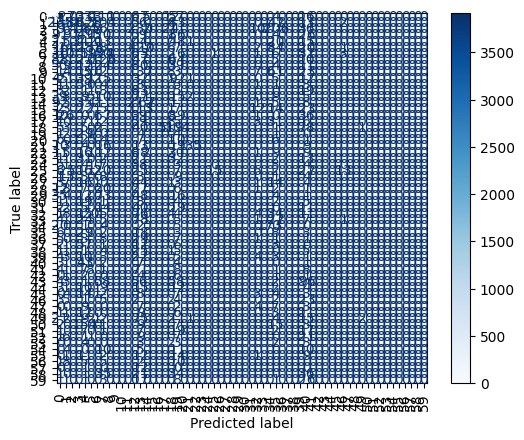

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(labels_np, top1.cpu().numpy())
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", xticks_rotation=90)
plt.show()


### Seen vs Unseen experiment

In [40]:
#prepare the mapping 
id_to_class = {v: k for k, v in action_label_to_idx.items()}

In [41]:
#labels = tensor(labels) and Z_p = tensor(latents)

classes_120 = list(action_label_to_idx.keys())[:120]
classes_seen = set(classes_120[:60])
classes_unseen = set(classes_120[60:120])

print("class seen", len(classes_seen))
print("class unseen", len(classes_unseen))
mask_seen = torch.tensor([id_to_class[int(l)] in classes_seen for l in labels])
mask_unseen = torch.tensor([id_to_class[int(l)] in classes_unseen for l in labels])

Z_seen, Z_unseen = Z_p[mask_seen], Z_p[mask_unseen]
labels_seen, labels_unseen = labels[mask_seen], labels[mask_unseen]

print("latent seen", len(Z_seen))
print("labels seen", len(labels_seen))
print("latent unseen", len(Z_unseen))
print("label unseen", len(labels_unseen))



class seen 60
class unseen 60
latent seen 18093
labels seen 18093
latent unseen 0
label unseen 0


In [42]:
def zero_shot_accuracy(Z_subset, labels_subset, E_text):
    S = Z_subset @ E_text.T

    top1 = torch.argmax(S, dim=1)
    labels_np = labels_subset.cpu().numpy()
    top1_acc = (top1.cpu().numpy() == labels_np).mean() * 100

    top5 = torch.topk(S, k=5, dim=1).indices
    correct_top5 = np.array([
        labels_np[i] in top5[i].cpu().numpy()
        for i in range(len(labels_np))
    ])
    top5_acc = correct_top5.mean() * 100

    return top1_acc, top5_acc

In [43]:
acc_seen_top1, acc_seen_top5 = zero_shot_accuracy(Z_seen, labels_seen, E_text)
acc_unseen_top1, acc_unseen_top5 = zero_shot_accuracy(Z_unseen, labels_unseen, E_text)

print(f"Seen Top-1 accuracy:  {acc_seen_top1:.2f}%")
print(f"Seen Top-5 accuracy:  {acc_seen_top5:.2f}%")
print(f"Unseen Top-1 accuracy: {acc_unseen_top1:.2f}%")
print(f"Unseen Top-5 accuracy: {acc_unseen_top5:.2f}%")

Seen Top-1 accuracy:  49.51%
Seen Top-5 accuracy:  60.56%
Unseen Top-1 accuracy: nan%
Unseen Top-5 accuracy: nan%


C:\Users\meenakshi\AppData\Local\Temp\ipykernel_36284\1726977862.py:6: RuntimeWarning: Mean of empty slice.
  top1_acc = (top1.cpu().numpy() == labels_np).mean() * 100
d:\anaconda3\envs\motionclip\lib\site-packages\numpy\core\_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
C:\Users\meenakshi\AppData\Local\Temp\ipykernel_36284\1726977862.py:13: RuntimeWarning: Mean of empty slice.
  top5_acc = correct_top5.mean() * 100


In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion(Z_subset, labels_subset, E_text, class_names, title, label_offset=0):
    """
    label_offset = minimum label value in this subset (e.g., 0 for seen, 60 for unseen)
    """
    S = Z_subset @ E_text.T
    preds = torch.argmax(S, dim=1).cpu().numpy()
    y_true = labels_subset.cpu().numpy()

    # Remap to local indices for subset
    preds_local = preds - label_offset
    y_true_local = y_true - label_offset

    # Ensure we only include valid labels
    valid_mask = (y_true_local >= 0) & (y_true_local < len(class_names))
    preds_local = preds_local[valid_mask]
    y_true_local = y_true_local[valid_mask]

    # Confusion matrix
    cm = confusion_matrix(y_true_local, preds_local, labels=np.arange(len(class_names)), normalize="true")

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(title)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


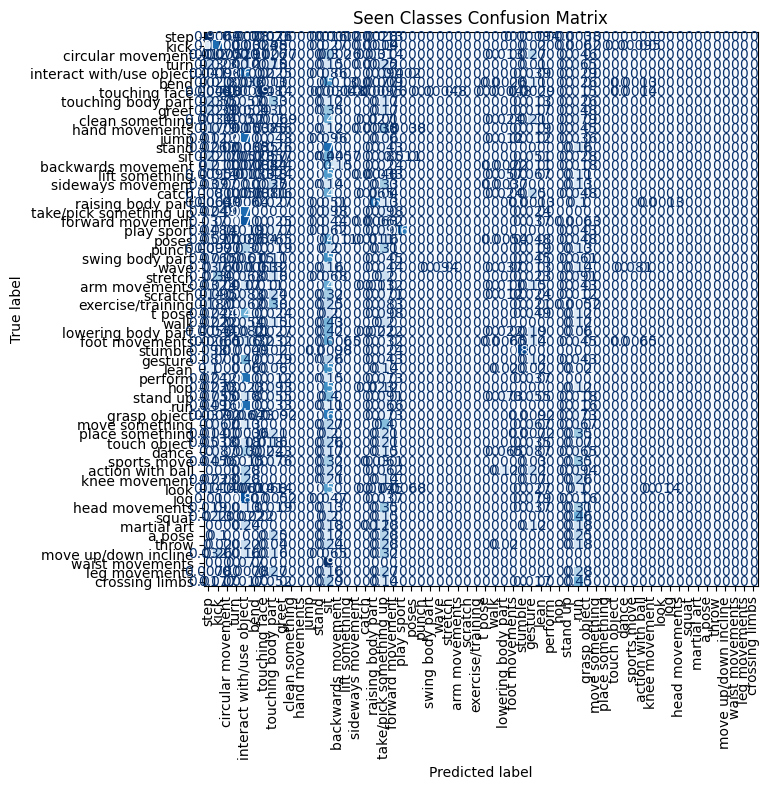

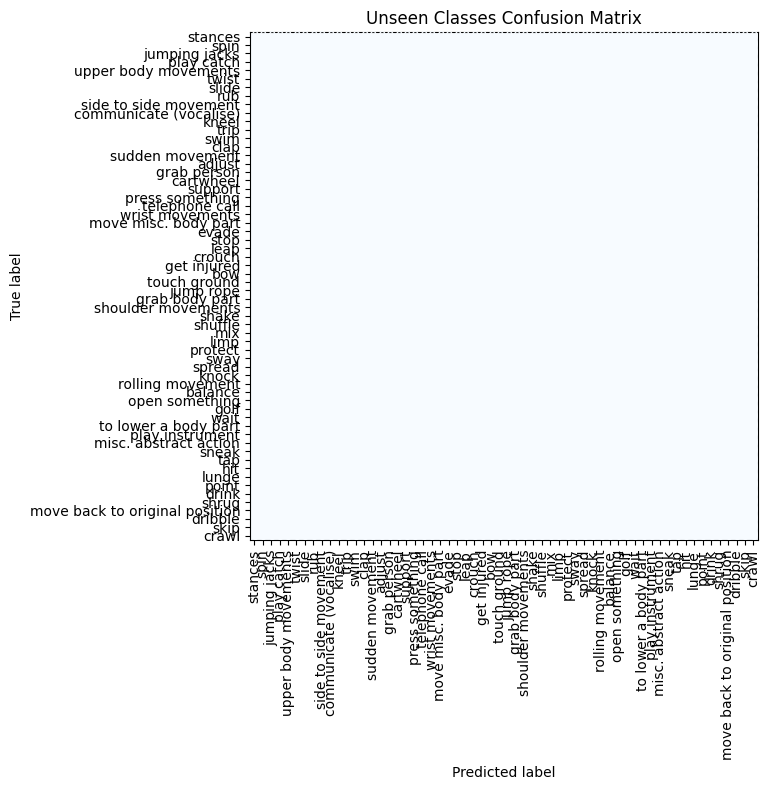

In [45]:
plot_confusion(Z_seen, labels_seen, E_text, list(classes_seen), "Seen Classes Confusion Matrix")
plot_confusion(Z_unseen, labels_unseen, E_text, list(classes_unseen), "Unseen Classes Confusion Matrix")